# Chess RL — Concept Discovery & Explainability

Unsupervised concept discovery over the trained KQK REINFORCE agent (v7).
Steps: activation extraction → sparse autoencoder → UMAP/HDBSCAN → visualisation.

In [1]:
import sys, os

from chess.engine import Opponent

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)


from explainability.sparse_autoencoder import train as train_ae, load_ae
from agents.v9.ppo_agent import PPOAgent, ActorCritic
from explainability.concept_discovery import run as run_umap
from explainability.activation_collector_ppo import collect
from explainability.visualizer import (
    build_concept_labels,
    build_concept_labels_tree,
    explain_move,
    plot_umap
)

import matplotlib.pyplot as plt
import pandas as pd
import chess.svg
import torch

## Cell 1 — Generate trunk activations

In [2]:
result = collect(n_positions=50000, seed=42, model_name='kqk_ppo_with_opponent_v1_stage_2.pt')
activations = result['activations']
fens        = result['fens']
print(f'Activations shape: {activations.shape}')  # (5000, 256)
print(f'Sample FEN: {fens[0]}')

Saved 50000 activations → /home/anass/School/chessMate/explainability/data/activations.npz
Activations shape: (50000, 256)
Sample FEN: 2Q5/4K3/8/8/8/8/8/k7 w - - 0 1


## Cell 2 — Train sparse autoencoder, show reconstruction loss curve

Epoch   10  loss=0.006552  best=0.006792  no_improve=0/20
Epoch   20  loss=0.004791  best=0.004936  no_improve=0/20
Epoch   30  loss=0.003912  best=0.003944  no_improve=0/20
Epoch   40  loss=0.003348  best=0.003368  no_improve=0/20
Epoch   50  loss=0.002928  best=0.002969  no_improve=1/20
Epoch   60  loss=0.002658  best=0.002630  no_improve=0/20
Epoch   70  loss=0.002390  best=0.002435  no_improve=2/20
Epoch   80  loss=0.002274  best=0.002243  no_improve=1/20
Epoch   90  loss=0.002093  best=0.002061  no_improve=0/20
Epoch  100  loss=0.001982  best=0.001960  no_improve=1/20
Epoch  110  loss=0.001882  best=0.001810  no_improve=0/20
Epoch  120  loss=0.001746  best=0.001749  no_improve=1/20
Epoch  130  loss=0.001715  best=0.001651  no_improve=0/20
Epoch  140  loss=0.001614  best=0.001596  no_improve=2/20
Epoch  150  loss=0.001633  best=0.001521  no_improve=4/20
Epoch  160  loss=0.001471  best=0.001437  no_improve=1/20
Epoch  170  loss=0.001544  best=0.001400  no_improve=1/20
Epoch  180  lo

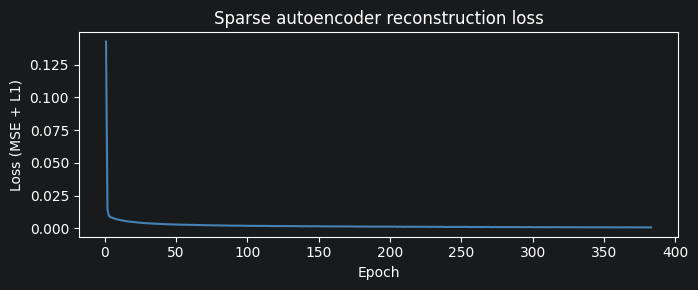

In [3]:
ae_model, losses = train_ae()

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(range(1, len(losses) + 1), losses, color='steelblue')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (MSE + L1)')
ax.set_title('Sparse autoencoder reconstruction loss')
plt.tight_layout()
plt.show()

## Cell 3 — UMAP scatter coloured by HDBSCAN cluster

Running UMAP…
UMAP done, shape=(50000, 2)
Running HDBSCAN…
HDBSCAN: 19 clusters, 2607 noise points
Saved UMAP results → /home/anass/School/chessMate/explainability/data/umap_results.npz


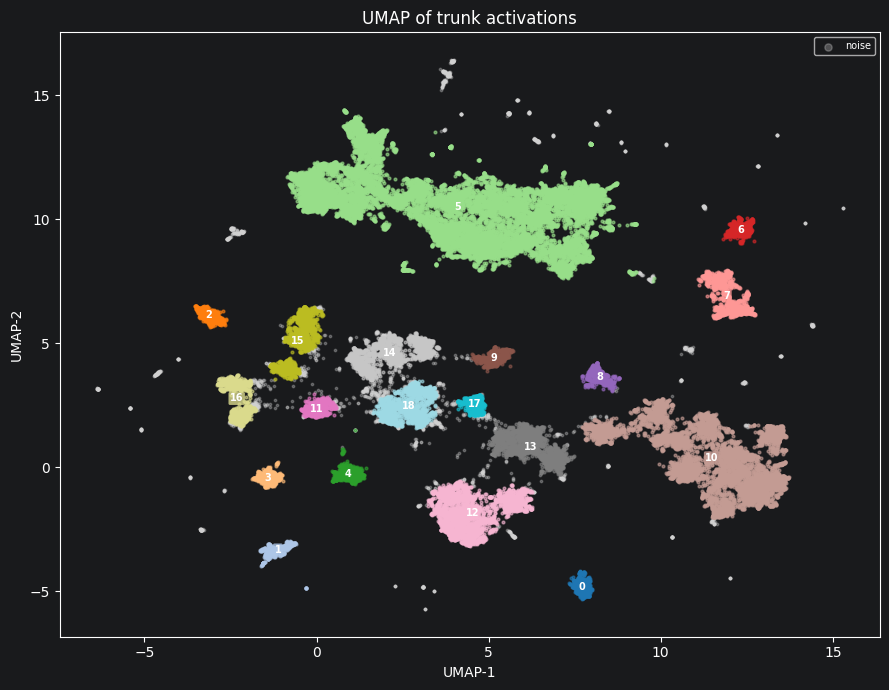

19 clusters discovered, 2607 noise points


In [4]:
umap_data = run_umap(seed=42)
coords    = umap_data['umap_coords']
labels    = umap_data['cluster_labels']

fig = plot_umap(coords, labels)
plt.show()

n_clusters = int(labels.max()) + 1
print(f'{n_clusters} clusters discovered, {(labels == -1).sum()} noise points')

## Cell 4 — Clusters descriptions

In [5]:
cluster_descriptions = umap_data.get('cluster_descriptions', {})

for c_id in range(n_clusters):
    desc = cluster_descriptions.get(c_id, '')
    print(f'\n=== Cluster {c_id} ===')
    if desc:
        print(f'  {desc}')


=== Cluster 0 ===
  BK corner zone: False (0%) | BK centrality: 2.00 (avg 0.81) | BK edge dist: 2.00 (avg 0.81)

=== Cluster 1 ===
  BK rank: 5.98 (avg 3.50) | BK in top half: True (99%) | BK in right half: True (99%)

=== Cluster 2 ===
  BK rank: 1.00 (avg 3.50) | BK in top half: False (0%) | BK in right half: True (100%)

=== Cluster 3 ===
  BK rank: 1.00 (avg 3.50) | BK in right half: False (0%) | BK in top half: False (0%)

=== Cluster 4 ===
  BK corner zone: False (0%) | BK centrality: 1.99 (avg 0.81) | BK edge dist: 1.99 (avg 0.81)

=== Cluster 5 ===
  BK file: 1.03 (avg 3.51) | BK in right half: False (1%) | BK-WK file signed: -2.77 (avg 0.01)

=== Cluster 6 ===
  BK on file h: True (100%) | BK file: 7.00 (avg 3.51) | BK-WK file signed: 3.96 (avg 0.01)

=== Cluster 7 ===
  BK on rank 8: True (100%) | BK rank: 7.00 (avg 3.50) | BK-WK rank signed: 3.70 (avg -0.00)

=== Cluster 8 ===
  BK corner zone: False (1%) | BK centrality: 1.99 (avg 0.81) | BK edge dist: 1.99 (avg 0.81)

===

## Cell 5 — Concept labelling (linear + tree)

In [21]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH = os.path.join(
    PROJECT_ROOT,
    "notebooks",
    "exploration",
    "models",
    "kqk_ppo_with_opponent_v1_stage_2.pt"
)

net = ActorCritic().to(DEVICE)
net.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=DEVICE
    )
)
net.eval()
trunk = net.backbone

ae = load_ae()

# Linear: enhanced features + composite top-3 correlation labels
print("=== Linear labels ===")
concept_labels_linear, label_table_linear = (
    build_concept_labels(
        ae,
        top_k_features=3,
        min_r_secondary=0.15
    )
)

# Nonlinear: decision tree per concept (max_depth=3)
print("\n=== Tree labels ===")
concept_labels_tree, label_table_tree = (
    build_concept_labels_tree(
        ae,
        max_depth=3
    )
)

agent = PPOAgent(
    curriculum_ratio=0.0
)
agent.net = net
frames, move_labels = agent.render_game(
    fen='k7/8/8/8/8/8/8/1Q2K3 w - - 0 1',
    greedy=True,
    movement="centrum"
)

=== Linear labels ===
333/512 alive concepts

=== Tree labels ===
333/512 alive concepts (tree, max_depth=3)
Using device: cuda


In [22]:
df_lin  = pd.DataFrame(label_table_linear[['concept_id', 'r', 'feature']]
                        ).rename(columns={'r': 'r_linear', 'feature': 'label_linear'})
df_tree = pd.DataFrame(label_table_tree[['concept_id', 'r2', 'feature']]
                        ).rename(columns={'r2': 'R2_tree', 'feature': 'label_tree'})

df = df_lin.merge(df_tree, on='concept_id').sort_values('r_linear', ascending=False)

print(f"Unique linear labels : {df['label_linear'].nunique()} / {len(df)}")
print(f"Unique tree   labels : {df['label_tree'].nunique()}  / {len(df)}")
df.head(30)

Unique linear labels : 136 / 333
Unique tree   labels : 293  / 333


,concept_id,r_linear,label_linear,R2_tree,label_tree
0,290,0.506024,BK in right half ↑ | BK file ↑ | BK-WK file si...,0.430785,BK in right half ∧ BK in top half ∧ BK rank ≤ 5.5
1,293,0.494283,BK file ↑ | BK in right half ↑ | BK-WK file si...,0.585126,BK file > 4.5 ∧ BK rank ≤ 3.5 ∧ BK file > 6.5
2,110,0.489966,BK file ↑ | BK in right half ↑ | BK on file h ↑,0.583296,BK file > 4.5 ∧ BK rank ≤ 3.5 ∧ BK file > 6.5
3,208,0.476139,BK file ↑ | BK in right half ↑ | BK in top half ↑,0.672750,BK file > 4.5 ∧ BK rank > 3.5 ∧ BK file > 5.5
4,494,0.451127,BK on file h ↑ | BK file ↑ | BK-WK file signed ↑,0.347594,BK file > 6.5 ∧ BK rank ≤ 1.5 ∧ BK mobility ≤ 2.5
5,35,0.442784,BK in right half ↑ | BK file ↑ | BK-WK file si...,0.241298,BK in right half ∧ Q rank ≤ 3.5 ∧ Q file ≤ 1.5
6,276,0.442492,BK in right half ↑ | BK file ↑ | BK-WK file si...,0.240975,BK in right half ∧ Q rank ≤ 3.5 ∧ Q file ≤ 1.5
7,373,0.438505,BK on rank 8 ↑ | BK rank ↑ | BK in top half ↑,0.518538,BK rank > 5.5 ∧ ¬BK in right half ∧ BK file > 2.5
8,79,0.422029,BK file ↑ | BK-WK file signed ↑ | BK in right ...,0.395386,BK file > 5.5 ∧ BK in top half ∧ WK→BK file ga...
9,120,0.406589,BK in right half ↑ | BK file ↑ | BK-WK file si...,0.255405,BK in right half ∧ Q file ≤ 4.5 ∧ BK-WK rank s...


## Cell 6 — Per-move concept explanations on a sample game

Set `concept_labels` to either `concept_labels_linear` or `concept_labels_tree`.

Move 1: Qb5


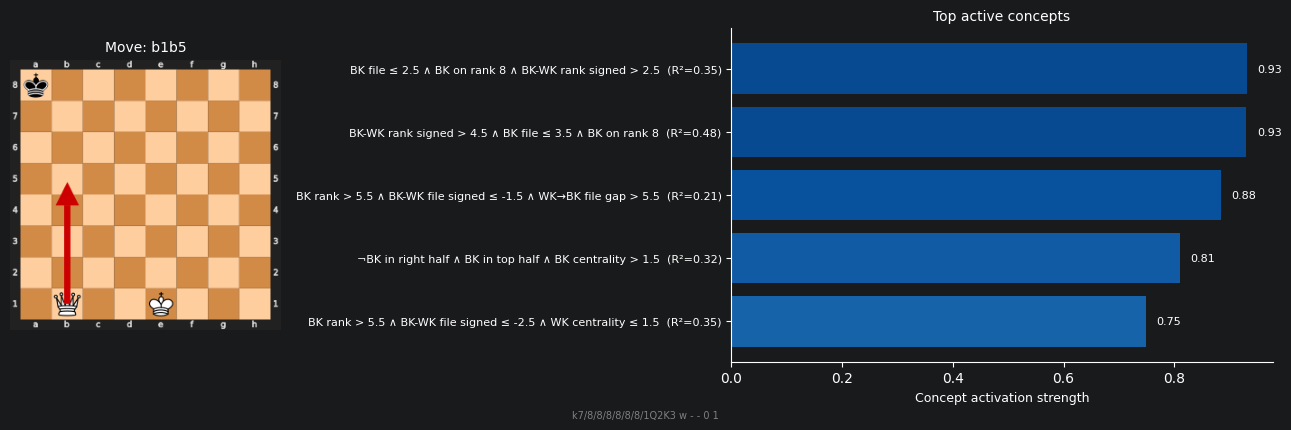

Move 2: Kd2


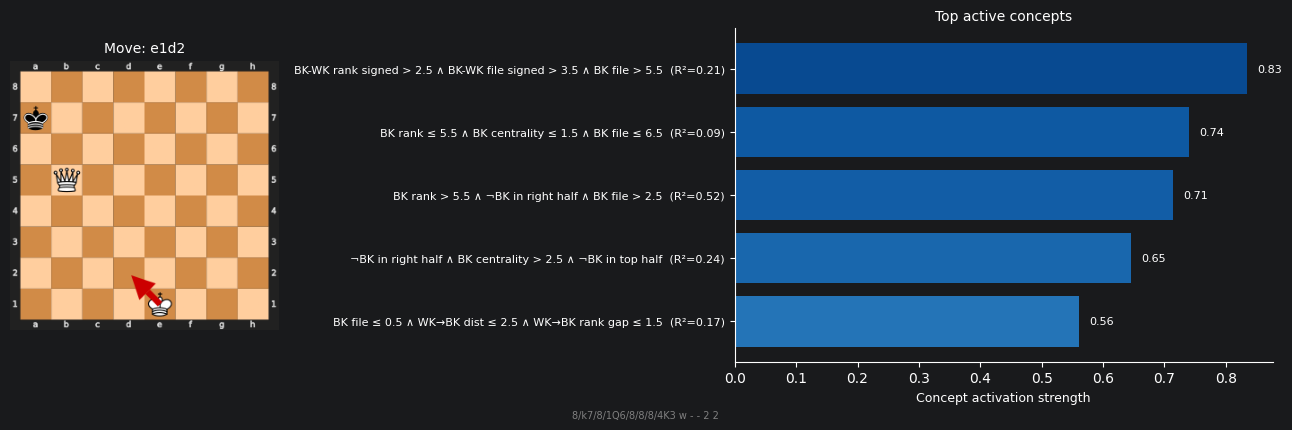

Move 3: Kc3


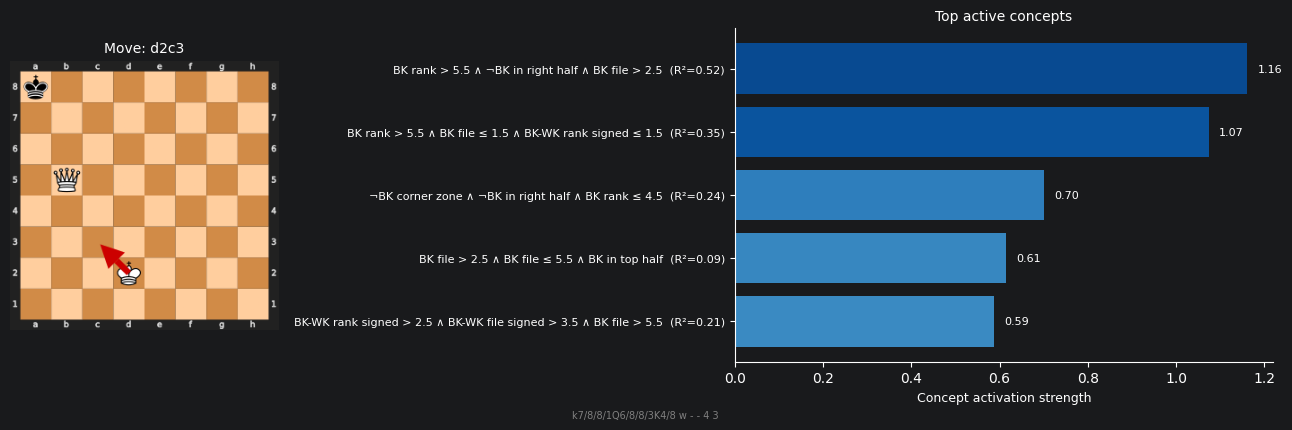

Move 4: Kc4


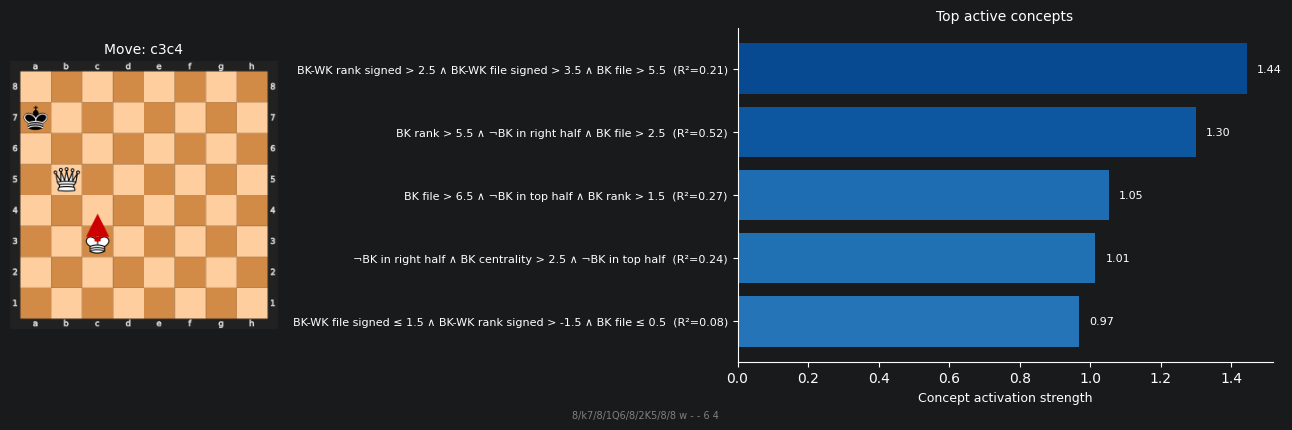

Move 5: Kd5


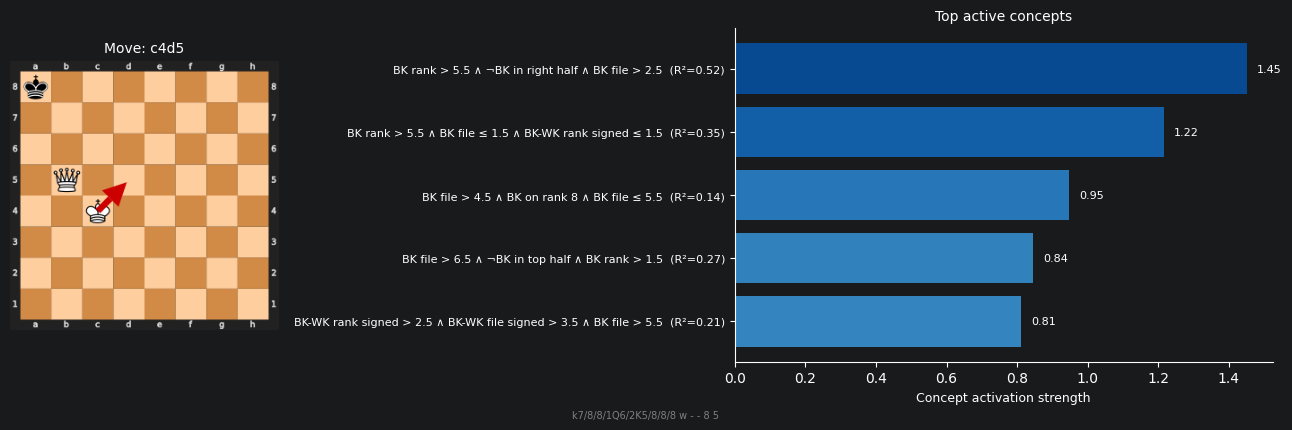

Move 6: Kd6


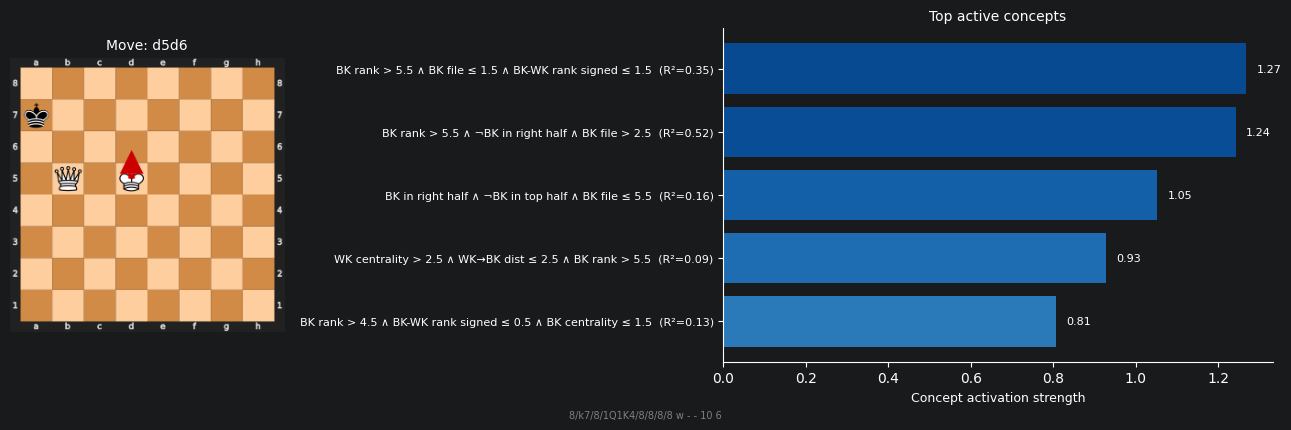

Move 7: Kc7


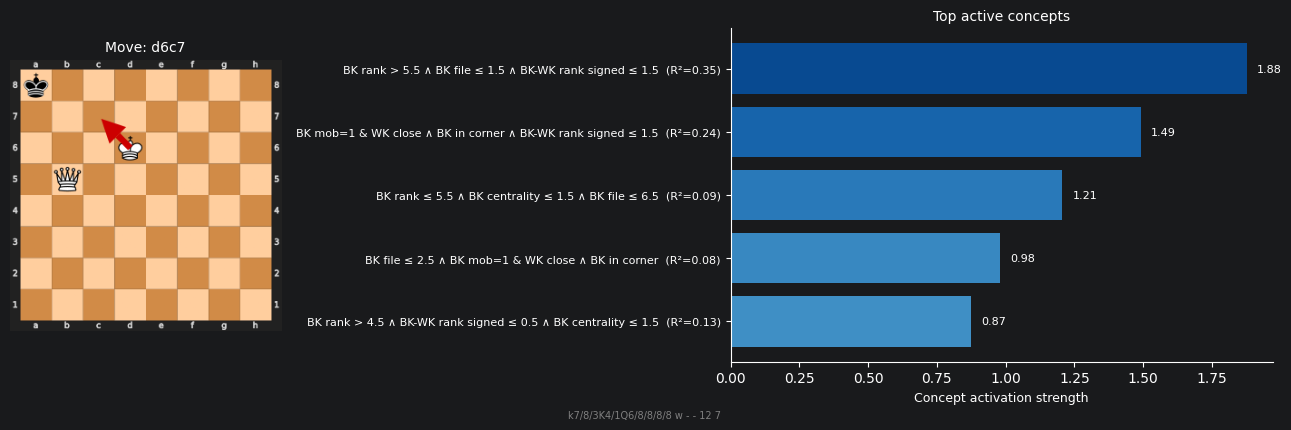

Move 8: Qa5#  — checkmate


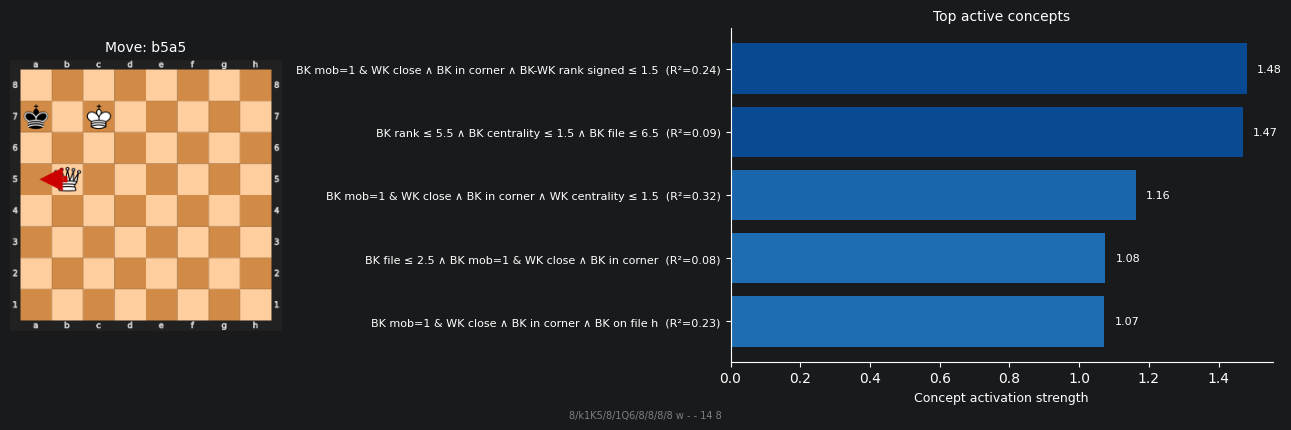

In [25]:
# Switch between 'concept_labels_linear' and 'concept_labels_tree'
concept_labels = concept_labels_tree

MAX_MOVES = 50
shown = 0
for frame, label in zip(frames[:-1], move_labels[1:]):
    if frame.turn != chess.WHITE:
        continue

    san_clean = label.split('—')[0].strip()
    try:
        move = frame.parse_san(san_clean)
    except Exception:
        continue

    print(f"Move {shown+1}: {label.strip()}")
    fig = explain_move(
        frame.fen(),
        move.uci(),
        ae,
        trunk,
        concept_labels,
        top_k=5
    )
    plt.show()

    shown += 1
    if shown >= MAX_MOVES:
        break

## Cell 7 — Linear probing

Train a logistic regression per binary board concept using the 256-dim trunk
activations as input. AUC > 0.75 means the concept is **linearly decodable** —
the agent internally tracks it without ever being trained to do so.

Concept                           AUC  Bal-Acc
------------------------------------------------
  BK in right half              0.999  0.985
  BK corner & Q near            0.998  0.822
  BK filea & Q→file             0.997  0.500
  BK on rank 8                  0.996  0.947
  BK in top half                0.995  0.966
  BK on file h                  0.995  0.948
  BK on file a                  0.994  0.942
  BK rank1 & Q→rank             0.987  0.600
  BK corner zone                0.987  0.927
  BK on rank 1                  0.987  0.910
  BK in corner                  0.985  0.862
  BK on edge                    0.983  0.934
  BK mobility=0                 0.915  0.554
  BK edge & Q near              0.875  0.537
  BK edge & mob≤1               0.871  0.556
  BK mob=1 & WK close           0.863  0.570
  BK mobility=1                 0.849  0.550
  WK on edge                    0.806  0.723
  Q-BK same rank                0.801  0.515
  Q on edge                     0.777  0.698
  Q-

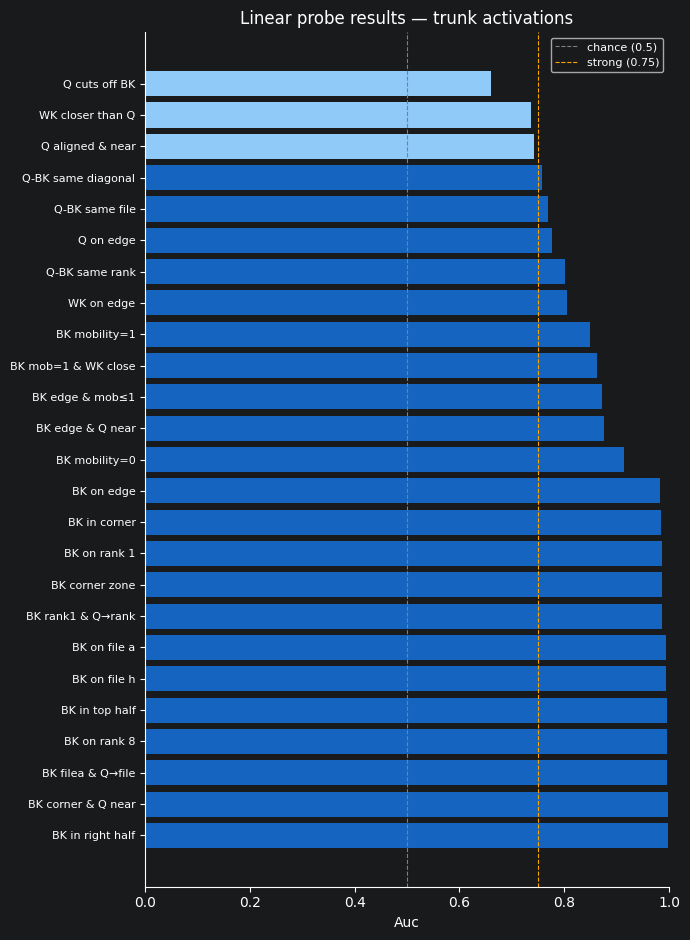

In [24]:
from explainability.linear_probe import probe_all, plot_probe_results

# Uses activations.npz already collected in Cell 1
probe_results = probe_all()

print(f"{'Concept':<30s}  {'AUC':>5s}  {'Bal-Acc':>7s}")
print("-" * 48)
for name, m in probe_results.items():
    print(f"  {name:<28s}  {m['auc']:.3f}  {m['balanced_accuracy']:.3f}")

fig = plot_probe_results(probe_results)
plt.show()

## Cell 8 — What–When–Where

Tracks **when** (training stage) and **where** (layer depth) each chess concept
is linearly decodable from the network's activations.
Rows = training stages, columns = concepts, colour = probe AUC (0.5 = chance, 1.0 = perfect).

[1/4] kqk_ppo_v2.pt…
[2/4] kqk_ppo_v2_stage_2.pt…
[3/4] kqk_ppo_v2_stage_3.pt…
[4/4] kqk_ppo_v2_stage_4.pt…


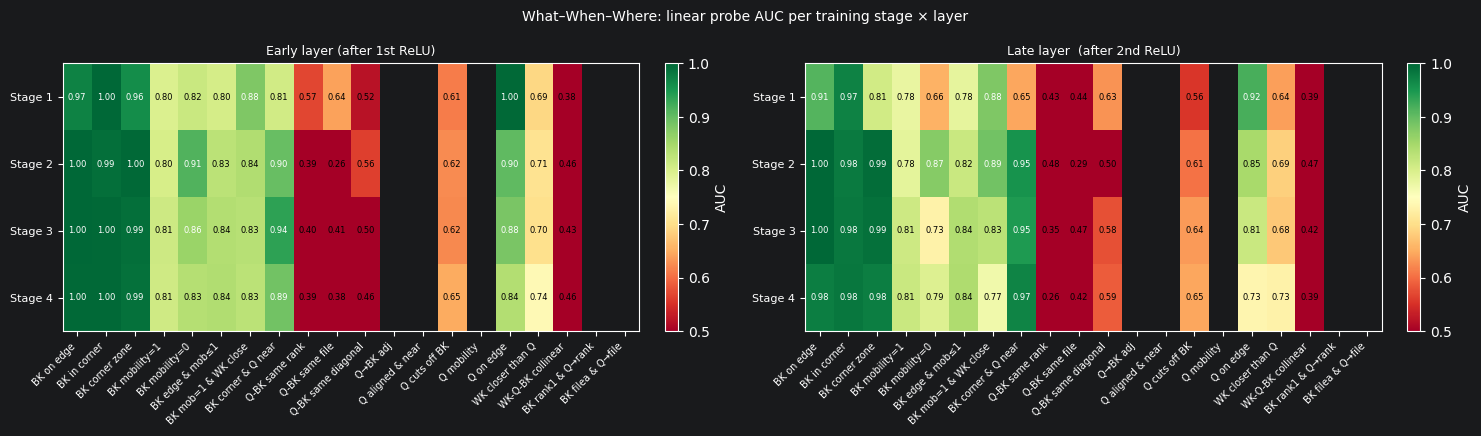

In [20]:
import numpy as np
from explainability.what_when_where import run as run_www, plot as plot_www

# Probes 4 staged checkpoints × 2 layers × 12 concepts (~2 min)
www_results = run_www()
fig = plot_www(www_results)
plt.show()

## Cell 9 — Saliency maps

For a chosen position + move, zero out each of the 64 squares' 12 input channels
one at a time and measure the drop in policy probability for that move.
The resulting 8×8 heatmap shows **which squares the agent was actually looking at**.

Greedy move: d6d8


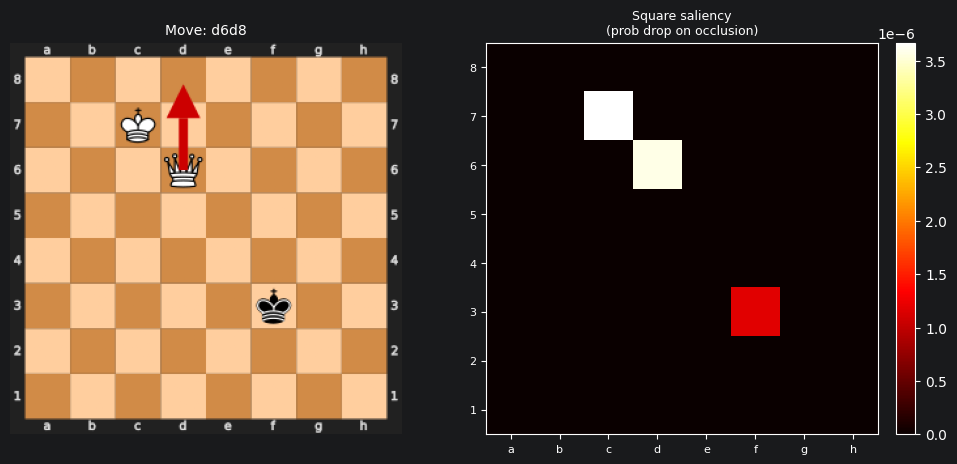

In [11]:
import chess
import utils.board as b
from explainability.saliency import square_saliency, plot_saliency

# Pick a position and let the agent choose its best move
fen_sal   = "8/2K5/3Q4/8/8/5k2/8/8 w - - 0 1"
board_sal = chess.Board(fen_sal)
legal_sal = list(board_sal.legal_moves)
acts_sal  = [b.move_to_action(m) for m in legal_sal]

with torch.no_grad():
    logits_sal, _ = net(
        torch.from_numpy(b.board_to_obs(board_sal)).float().unsqueeze(0).to(DEVICE)
    )
best_move = legal_sal[
    int(torch.tensor([logits_sal[0, a] for a in acts_sal]).argmax())
].uci()
print(f"Greedy move: {best_move}")

smap = square_saliency(fen_sal, best_move, net)
fig  = plot_saliency(fen_sal, best_move, smap)
plt.show()

## Cell 10 — Behavioral analysis

Run the greedy agent from 2000 random positions (black moves randomly) and record:
- **Mate heatmap** — which squares the black king gets mated on
- **Length distribution** — how many halfmoves each game takes
- **Entropy across stages** — how decisive/systematic the policy becomes over training

In [12]:
from collections import Counter
from explainability.behavioral import (
    collect_trajectories,
    plot_mate_heatmap,
    plot_length_distribution,
    plot_entropy_across_stages,
    _load_opponent_net,
    DEFAULT_OPPONENT_MODEL,
)

opponent_net = _load_opponent_net(DEFAULT_OPPONENT_MODEL)

stats = collect_trajectories(net, n_episodes=50_000, opponent_net=opponent_net)

n_mate = sum(o == "checkmate" for o in stats["outcomes"])
print(f"Checkmate rate : {100 * n_mate / 50_000:.1f}%")
print(f"Median length  : {np.median(stats['lengths']):.0f} plies")
print(f"Mean H(π)      : {np.nanmean(stats['entropies']):.3f}")
print()
for zone, cnt in Counter(stats["mate_zones"]).most_common():
    print(f"  {zone:<8s}: {cnt}  ({100 * cnt / max(n_mate, 1):.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_mate_heatmap(stats["mate_squares"], ax=axes[0])
plot_length_distribution(stats["lengths"], ax=axes[1])
plt.tight_layout()
plt.show()

# Entropy drop across training stages (lower = more decisive play)
fig = plot_entropy_across_stages(
    n_episodes=50_000,
    opponent_net=opponent_net,
    model_names=[
        "kqk_ppo_v2_stage_4.pt",
        "kqk_ppo_with_opponent_v1_stage_2.pt",
        "kqk_ppo_v1_stage_2.pt",
        "kqk_ppo_v1.pt",
    ]
)
plt.show()

KeyboardInterrupt: 